## 1. What this notebook computes

A thermal Kohn-Sham state (temperature $T > 0$) fills its levels with the
Fermi-Dirac occupations, and one number, the **chemical potential** $\mu$, is fixed
by the condition that the occupations add up to the particle number $N$. The first
cross-check of the two Kohn-Sham solvers (the Rust solver and the independent Python
reference solver) FAILED on exactly this number: in the state N8_lamm1_a00_T10 the
two values of $\mu$ differed by $8.27\times10^{-10}$ (in units of the mass $m$),
about 100 times the tolerance that had been fixed before the comparison. This
notebook reconstructs the diagnosis and the repair from the records:

- it reads the final levels of that state from both solvers and computes $\mu$ again
  with **40 significant digits** (Newton's method, with the package mpmath); this
  decides which value was right;
- it shows why the ordinary numbers of a computer (about 16 digits) cannot locate
  $\mu$ better than about $10^{-9}$ when the occupations are simply added up: the
  computed sum is a **staircase** with steps of about $10^{-15}$;
- it reproduces the faulty value of the first cross-check, in all the digits the
  record prints, by bisection on that direct sum, and the correct value by the
  **well-conditioned** form of the condition that both solvers use now;
- it computes the **rounding bounds** that predict the size of such errors and
  reproduces those of the Rust solver's 40-digit report;
- for all 45 thermal states with $N = 8$ it repeats the cross-check's 40-digit
  comparison for both solvers, reproduces its table rows, and shows where the direct
  sum fails;
- it draws six figures.

It needs no Rust and runs in about half a minute.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 16c (How the cross-check caught a rounding error: the Mermin root) is the file
`Revision/textbook/notebooks/16c_mermin_root.ipynb` of the repository Dirac_claude. The
first cross-check of the two Kohn-Sham solvers failed on the chemical potential of one
thermal state. This notebook reconstructs the diagnosis and the repair from the records:
it computes the chemical potential of that state with 40 significant digits by Newton's
method from the final levels of both solvers, shows why ordinary computer numbers locate
it only to about one part in a billion when the occupations are simply added up,
reproduces the faulty value of the first cross-check by bisection on that direct sum and
the correct value by the well-conditioned form that both solvers use now, computes the
rounding bounds that predict such errors, and repeats the 40-digit comparison of the
cross-check for all 45 thermal states with eight particles, reproducing the recorded
roots, bounds, tolerances and ratios. It needs a computer with Windows 11, macOS or
Linux, an internet connection for the installation, the program Git, and Python 3.12 or
newer (the notebooks were built with Python 3.14.5) with these packages at exactly these
versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10,
nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook
itself imports numpy, mpmath and matplotlib; the other packages run Jupyter, the program
that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 16c_mermin_root.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 1 minute on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 16c_mermin_root.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
16c_mermin_root.ipynb` (in the same folder, without running the cells again) to read the
printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/16c.captions.json`
- `Revision/textbook/figures/16c_1_levels_and_occupations.png`
- `Revision/textbook/figures/16c_2_residual_staircase.png`
- `Revision/textbook/figures/16c_3_convergence_paths.png`
- `Revision/textbook/figures/16c_4_errors_versus_bound.png`
- `Revision/textbook/figures/16c_5_conditioning_map.png`
- `Revision/textbook/figures/16c_6_crosscheck_ratios.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS every figure file of this notebook exists
    ALL 26 CHECKS PASSED (notebook 16c)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/16c_mermin_root.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4. If the environment is active and the message stays, the programs
  jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
  programs (`python -m jupyter` does not help then: it has to find the same programs).
  Start them through Python itself, in the folder of the notebook: the first command
  below does what `jupyter lab` does, the second what the headless command does:

      python -m jupyterlab 16c_mermin_root.ipynb
      python -m nbconvert --execute --inplace 16c_mermin_root.ipynb

- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- The cell that computes the 40-digit roots of the 45 states runs for half a minute or
  longer: this is normal. Numbers with 40 digits are computed by Python itself, not by
  the processor, so each operation is about a thousand times slower; the cell does about
  a hundred thousand of them. Wait until the label shows a number.
- An AssertionError names a comparison with a record: the reference results, the Rust
  results or a report were changed. Get the stored versions back and run the notebook
  again.

      git checkout -- Revision/kohn_sham

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 16c (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 16c (How the cross-check caught a rounding error: the Mermin root) is the file
# Revision/textbook/notebooks/16c_mermin_root.ipynb of the repository Dirac_claude. The
# first cross-check of the two Kohn-Sham solvers failed on the chemical potential of one
# thermal state. This notebook reconstructs the diagnosis and the repair from the
# records: it computes the chemical potential of that state with 40 significant digits by
# Newton's method from the final levels of both solvers, shows why ordinary computer
# numbers locate it only to about one part in a billion when the occupations are simply
# added up, reproduces the faulty value of the first cross-check by bisection on that
# direct sum and the correct value by the well-conditioned form that both solvers use
# now, computes the rounding bounds that predict such errors, and repeats the 40-digit
# comparison of the cross-check for all 45 thermal states with eight particles,
# reproducing the recorded roots, bounds, tolerances and ratios. It needs a computer with
# Windows 11, macOS or Linux, an internet connection for the installation, the program
# Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these
# packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib
# 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and
# nbconvert 7.16.6. The notebook itself imports numpy, mpmath and matplotlib; the other
# packages run Jupyter, the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 16c_mermin_root.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 1 minute
# on a typical laptop. Scroll to the end and compare the last printed lines with the
# lines in the step "What the notebook writes and what you must see" below. To keep the
# results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose the
# menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 16c_mermin_root.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 16c_mermin_root.ipynb (in the same folder, without running the cells again) to read the
# printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/16c.captions.json
# - Revision/textbook/figures/16c_1_levels_and_occupations.png
# - Revision/textbook/figures/16c_2_residual_staircase.png
# - Revision/textbook/figures/16c_3_convergence_paths.png
# - Revision/textbook/figures/16c_4_errors_versus_bound.png
# - Revision/textbook/figures/16c_5_conditioning_map.png
# - Revision/textbook/figures/16c_6_crosscheck_ratios.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS every figure file of this notebook exists
#     ALL 26 CHECKS PASSED (notebook 16c)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/16c_mermin_root.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4. If the environment is active and the message stays, the programs
#   jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
#   programs (python -m jupyter does not help then: it has to find the same programs).
#   Start them through Python itself, in the folder of the notebook: the first command
#   below does what jupyter lab does, the second what the headless command does:
#     python -m jupyterlab 16c_mermin_root.ipynb
#     python -m nbconvert --execute --inplace 16c_mermin_root.ipynb
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - The cell that computes the 40-digit roots of the 45 states runs for half a minute or
#   longer: this is normal. Numbers with 40 digits are computed by Python itself, not by
#   the processor, so each operation is about a thousand times slower; the cell does
#   about a hundred thousand of them. Wait until the label shows a number.
# - An AssertionError names a comparison with a record: the reference results, the Rust
#   results or a report were changed. Get the stored versions back and run the notebook
#   again.
#     git checkout -- Revision/kohn_sham
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "16c"  # this notebook: chapter 16, example c


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 16c complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Level** $\varepsilon_i$: an allowed one-particle energy of the Kohn-Sham problem
  (units of the mass $m$). **Degeneracy** $g_i$: the number of states with that
  energy. In this model $g = 4\,r_3(n_2)$, where $n_2 = |\vec n|^2$ labels the shell
  of the 3-space momentum and $r_3(n_2)$ counts the whole-number points
  $(a, b, c)$ with $a^2 + b^2 + c^2 = n_2$ (the factor 4 counts four blocks of the
  spinor equation).
- **Fermi-Dirac occupation** $f(x) = 1/(1 + e^x)$ with $x = (\varepsilon - \mu)/T$:
  the average number of particles in one state; it lies between 0 and 1.
- **Chemical potential** $\mu$: the energy at which the occupation is one half.
- **Mermin condition**: $N(\mu) = \sum_i g_i\,f(x_i) = N$, the equation that fixes
  $\mu$. Its solution is called the **root**.
- **Gap**: an energy interval without levels. When the gap is much larger than $T$
  the state is in the **activated regime**: very few particles are thermally lifted
  across it.
- **Thermal holes** $H_{th} = \sum_{\varepsilon_i < \mu} g_i\,(1 - f(x_i))$ (missing
  particles below $\mu$) and **thermal particles**
  $P = \sum_{\varepsilon_i > \mu} g_i\,f(x_i)$ (particles above $\mu$).
- **Newton's method** and **bisection**: two ways to find a root, explained where
  they are used.
- **Double**: the ordinary number of a computer, with 53 binary digits (about 16
  decimal digits). **Machine epsilon** $\epsilon_{mach} = 2^{-52} \approx
  2.2\times10^{-16}$: the relative distance between neighbouring doubles near 1.
- **Rounding error**: the difference between the exact result of an operation and
  the double that the computer stores.
- **40-digit arithmetic**: numbers with 40 significant decimal digits, computed by
  the package mpmath (slow, but exact far beyond what is needed here).
- **Residual**: the left side minus the right side of an equation,
  $N(\mu) - N$; it is zero at the root.
- **Conditioning**: how strongly a small error of the residual moves the root.
  **Rounding bound**: an upper limit for the error of a computed root.
- **Tolerance** and **ratio** of the cross-check: the largest difference allowed
  between the two solvers, $3(U_{ref} + U_{Rust}) + 10^{-12}\max(1, |x|)$, and the
  difference divided by it; a comparison passes when the ratio is at most 1.
- **State id** such as `N8_lamm1_a00_T10`: $N = 8$ particles, coupling
  $-\lambda_1$ (`lam0`: $\lambda = 0$; `lamp1`: $+\lambda_1$; `lamm1`:
  $-\lambda_1$), slice $a_{4,0} = 0$ (the digits are ten times $a_{4,0}$),
  temperature $T = 0.01$ (`T10`; `T20`: 0.02; `T50`: 0.05; units of $m$).

## 4. The physical and mathematical situation

**The states.** The Kohn-Sham states of the fermion field dirac16complex are computed
at five instants (slices $a_{4,0} = 0, 0.5, 1, 1.5, 2$) of the PRESCRIBED BACKGROUND
history $a_4 = A H x_4$ of the author's metric: 3-space $x_1, x_2, x_3$ inflates with
the scale factor $e^{a_4}\sin^{1/6} z$, while the three extra times $x_5, x_6, x_7$
DEFLATE exponentially with $e^{-a_4}\sin^{1/6} z$; $x_4$ is the time and $x_8$ the
hidden direction. The 135 thermal states of the canonical matrix have
$N = 8, 136, 688$ particles, couplings $\lambda = 0, \pm\lambda_1$, the five slices
and $T = 0.01, 0.02, 0.05$. For each, both solvers compute the self-consistent levels
$\varepsilon_i$ and then $\mu$ from the Mermin condition
$$N(\mu) = \sum_i g_i\, f\!\left(\frac{\varepsilon_i - \mu}{T}\right) = N,
\qquad f(x) = \frac{1}{1 + e^x}.$$

**The slope of $N(\mu)$, line by line.**

- $f(x) = (1 + e^x)^{-1}$, so by the chain rule
  $f'(x) = -(1 + e^x)^{-2}\,e^x$.
- $\dfrac{e^x}{(1 + e^x)^2} = \dfrac{1}{1 + e^x}\cdot\dfrac{e^x}{1 + e^x}
  = f(x)\,(1 - f(x))$, because $1 - f(x) = \dfrac{e^x}{1 + e^x}$.
- So $f'(x) = -f(x)(1 - f(x))$.
- With $x = (\varepsilon - \mu)/T$ we have $dx/d\mu = -1/T$, and the chain rule gives
  $\dfrac{dN}{d\mu} = \sum_i g_i\, f'(x_i)\,\left(-\dfrac{1}{T}\right)
  = \dfrac{1}{T}\sum_i g_i\, f(x_i)(1 - f(x_i))$.
- Every term is positive, so $N(\mu)$ increases with $\mu$ and the root is unique.

**The activated regime.** In N8_lamm1_a00_T10 the eight particles exactly fill the
two lowest levels (each 4-fold, at $\varepsilon \approx 0.00025$); the next level
lies at $0.43$, so the gap is 43 times $T = 0.01$. Then $\mu$ sits near the middle
of the gap, where the few thermal holes below balance the few thermal particles
above, and $f(1 - f)$ is tiny for every level: $dN/d\mu \approx 10^{-6}$. A flat
$N(\mu)$ makes the root hard to locate: an error $\delta$ of the computed residual
moves the root by $\delta/(dN/d\mu)$ (the tangent line), a million times more.

**The history (records).** The cross-check compares every number of the two solvers
with the rule $|x_{Rust} - x_{ref}| \le 3(U_{ref} + U_{Rust}) +
10^{-12}\max(1,|x|)$, fixed in the program before any comparison. Its first run, on
a subset of the states, failed the check `thermo_state_functions` in
N8_lamm1_a00_T10: the Rust $\mu$ was $0.2100104489071649$, the reference $\mu$
$0.2100104497343054$, a difference of $8.27\times10^{-10}$ against a tolerance of
$7.97\times10^{-12}$. The tolerance was NOT widened. Instead the checker recomputed
$\mu$ with 40 digits from each solver's own levels: the two 40-digit roots agreed to
$4\times10^{-13}$, so the levels agreed and the Rust root was wrong. The Rust
solver computed $\mu$ by bisection on the direct sum $\sum g f - N$; it was repaired
(file `solver/src/mermin.rs`). The reference solver had the same defect in its first
complete run (its $\mu$ missed its own 40-digit root by $1.15\times10^{-9}$ in the same
state); it was repaired the same way. This notebook repeats each step of that
diagnosis with numbers it computes itself.

## 5. The levels of the state N8_lamm1_a00_T10

The next cell reads, for the state N8_lamm1_a00_T10, the final levels of the Rust
solver (stored with its canonical numerics in the cross-check's measurement file
`rust-refinement.json`), the final levels of the reference solver (its result file
`thermo/N8_lamm1_a00_T10.json`; the degeneracy is computed from the shell $n_2$ as
$4\,r_3(n_2)$), and the committed values of $\mu$ of both solvers. It also reads the
numbers of the history from the two README files with a text pattern, so that the
notebook uses the recorded values, not copies typed by hand. It prints the levels
side by side and checks that both solvers have the same levels (within their
uncertainties) and the same filling.

In [2]:
import csv  # reads tables stored as CSV files (comma-separated values)
import math  # functions of single numbers (isqrt, log10, ...)
import re  # finds patterns in text (used to read numbers out of sentences)
import sys  # the list of folders in which Python looks for modules
from functools import lru_cache  # remembers the results of a function

import mpmath as mp  # numbers with as many digits as we ask for
import numpy as np  # arrays of numbers

KS = "Revision/kohn_sham"  # the folder of the Kohn-Sham record (repository path)
STATE = "N8_lamm1_a00_T10"  # the state in which the first cross-check failed
EPS_MACH = 2.0 ** -52  # machine epsilon: neighbouring doubles near 1 differ by this
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300",
           "#4a3aa7", "#e34948"]  # the colours of the figures, in a fixed order


def read_json(relative):
    """Read a JSON file of the repository (a Revision record)."""
    return json.loads(repository_file(relative).read_text(encoding="utf-8"))


def read_csv(relative):
    """Read a CSV file of the repository: a list of rows, each row a dictionary from
    the column names to the texts in that row."""
    with open(repository_file(relative), newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))


@lru_cache(maxsize=None)
def r3(n2):
    """The number of whole-number points (a, b, c) with a^2 + b^2 + c^2 = n2."""
    R = math.isqrt(n2) + 1  # no coordinate can be larger than this
    return sum(1 for a in range(-R, R + 1) for b in range(-R, R + 1)
               for c in range(-R, R + 1) if a * a + b * b + c * c == n2)


RUST_MU = {r["id"]: float(r["mu"])
           for r in read_csv(f"{KS}/results/thermo/thermodynamics.csv")}
REFINEMENT = {s["id"]: s for s in read_json(f"{KS}/checker/rust-refinement.json")
              ["states"] if s["kind"] == "thermo"}


def state_data(sid):
    """Everything this notebook needs about one thermal state, from the records."""
    rust = REFINEMENT[sid]  # the Rust run with the canonical numerics
    ref = read_json(f"{KS}/reference/results/thermo/{sid}.json")
    T, N = rust["canonical_T_N"]
    return {"id": sid, "T": T, "N": N,
            "eps_rust": np.array([e for e, g in rust["canonical_levels_eps_deg"]]),
            "g_rust": np.array([g for e, g in rust["canonical_levels_eps_deg"]]),
            "eps_ref": np.array(ref["levels"]["eps"]),
            "g_ref": np.array([4.0 * r3(k[0]) for k in ref["levels"]["keys"]]),
            "keys_ref": ref["levels"]["keys"],
            "U_levels_ref": max(ref["levels"]["U"]),  # largest level uncertainty
            "mu_rust": RUST_MU[sid], "mu_ref": ref["thermo"]["mu"]["value"],
            "U_mu_ref": ref["thermo"]["mu"]["U"]}


S = state_data(STATE)
print(" i  key (n2:j:parity:rank)   g   eps reference        eps Rust")
for i, key in enumerate(S["keys_ref"]):
    rust = f"{S['eps_rust'][i]:.15f}" if i < len(S["eps_rust"]) else "(not kept)"
    print(f"{i:2d}  {key[0]}:{key[1]:+d}:{key[2]}:{key[3]}"
          f"{'':12s}{S['g_ref'][i]:3.0f}   {S['eps_ref'][i]:.15f}   {rust}")
common = len(S["eps_rust"])  # the Rust label set keeps one level fewer
say(f"T = {S['T']}, N = {S['N']}; committed mu: Rust {S['mu_rust']!r}, reference "
    f"{S['mu_ref']!r}")
check(np.array_equal(S["g_rust"], S["g_ref"][:common])
      and np.max(np.abs(S["eps_rust"] - S["eps_ref"][:common])) < 1e-11,
      "both solvers have the same levels (to 1e-11) and degeneracies")
check(np.sum(S["g_rust"][S["eps_rust"] < 0.2]) == S["N"],
      "the eight particles exactly fill the two levels below the gap")

checker_history = repository_file(f"{KS}/checker/README.md").read_text(
    encoding="utf-8")
found = re.search(r"Rust.s mu was ([0-9.]+) and the reference.s\s+([0-9.]+) "
                  r"\(\|diff\| ([0-9.e-]+) against a tolerance of ([0-9.e-]+)\)",
                  checker_history)
MU_OLD_RUST, MU_OLD_REF, DIFF_OLD, TOL_OLD = (float(x) for x in found.groups())
reference_history = repository_file(f"{KS}/reference/README.md").read_text(
    encoding="utf-8")
REF_OLD_MISS = float(re.search(r"this mu differed by ([0-9.e-]+) from the 40-digit",
                               reference_history).group(1))
say(f"history: Rust mu {MU_OLD_RUST!r}, reference mu {MU_OLD_REF!r}, |diff| "
    f"{DIFF_OLD:.3g}, tolerance {TOL_OLD:.3g}; reference first run missed its root "
    f"by {REF_OLD_MISS:.3g}")
check(abs(MU_OLD_RUST - MU_OLD_REF) - DIFF_OLD < 5e-13 and DIFF_OLD > TOL_OLD,
      "the recorded difference exceeds the recorded tolerance",
      record=f"{KS}/checker/README.md, History 1")

 i  key (n2:j:parity:rank)   g   eps reference        eps Rust
 0  0:+1:even:0              4   0.000245562707576   0.000245562707576
 1  0:-1:even:0              4   0.000245562707576   0.000245562707576
 2  1:+1:even:0             24   0.430761462627430   0.430761462626626
 3  2:+1:even:0             48   0.587973061749916   0.587973061748854
 4  3:+1:even:0             32   0.704111587085657   0.704111587084438
 5  4:+1:even:0             24   0.799655571340359   0.799655571339050
 6  5:+1:even:0             96   0.882327953674313   0.882327953672962
 7  6:+1:even:0             96   0.956014380953183   (not kept)
T = 0.01, N = 8.0; committed mu: Rust 0.2100104497339036, reference 0.21001044973430544
PASS both solvers have the same levels (to 1e-11) and degeneracies
PASS the eight particles exactly fill the two levels below the gap
history: Rust mu 0.2100104489071649, reference mu 0.2100104497343054, |diff| 8.27e-10,
    tolerance 7.97e-12; reference first run missed its root by 1.15

The next figure shows the state. Left: the occupation $f$ as a function of the
energy, a step from 1 to 0 that is $T = 0.01$ wide and sits at $\mu$, with the
levels as vertical lines; the two lowest levels are full, all others empty, and
$\mu$ lies in the middle of the gap. Right: the same occupations on a logarithmic
scale: the thermal holes $g(1 - f)$ of the two full levels and the thermal particles
$g f$ of the empty levels, at the committed $\mu$ of the reference. The holes and the
particles are each about $6\times10^{-9}$ and balance each other; the empty levels
above the first one hardly matter.

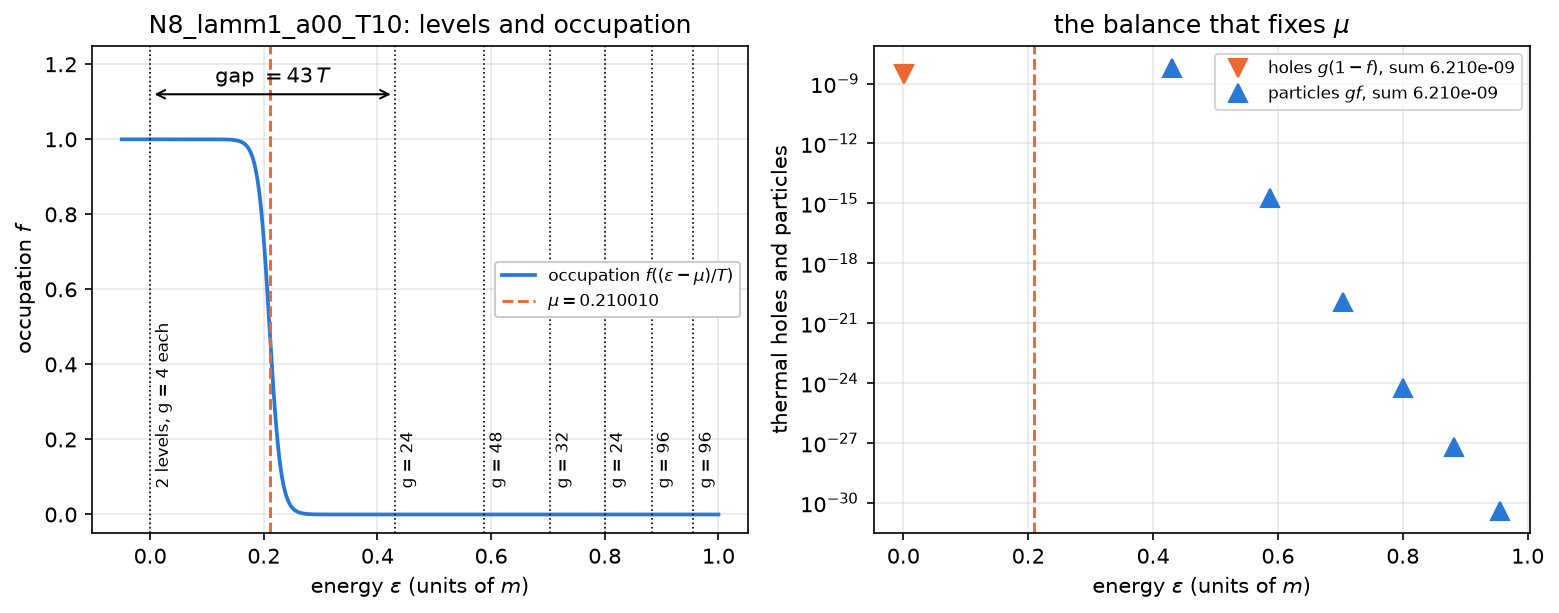

Figure 16c.1 saved as Revision/textbook/figures/16c_1_levels_and_occupations.png
holes 6.210359e-09, particles 6.210359e-09, difference -6.62e-24
PASS at the committed mu the thermal holes and particles balance (to 1e-15)


In [3]:
sys.dont_write_bytecode = True  # do not write a __pycache__ folder into the record
sys.path.insert(0, str(repository_file(f"{KS}/reference")))  # Python looks here too
import ks_fd as K  # noqa: E402  the reference solver's module (Revision code)

eps, g, T, N = S["eps_ref"], S["g_ref"], S["T"], S["N"]
mu = S["mu_ref"]
x = (eps - mu) / T
below = eps < mu
holes = g * K.fermi(-x)  # g (1 - f): f(-x) = 1 - f(x), computed without subtracting
particles = g * K.fermi(x)  # g f
fig, (left, right) = plt.subplots(1, 2, figsize=(10.5, 4.2))
energies = np.linspace(-0.05, 1.0, 2001)
left.plot(energies, K.fermi((energies - mu) / T), color=PALETTE[0], lw=1.8,
          label="occupation $f((\\varepsilon - \\mu)/T)$")
for e in np.unique(eps):  # one dotted line per energy, labelled with its states
    left.axvline(e, color="k", lw=0.8, ls=":")
    states = g[eps == e]
    label = (f"g = {states[0]:.0f}" if len(states) == 1
             else f"{len(states)} levels, g = {states[0]:.0f} each")
    left.text(e + 0.008, 0.08, label, rotation=90, fontsize=8)
left.axvline(mu, color=PALETTE[1], lw=1.4, ls="--", label=f"$\\mu = {mu:.6f}$")
left.annotate("", (eps[2], 1.12), (eps[1], 1.12), arrowprops={"arrowstyle": "<->"})
left.text(0.5 * (eps[1] + eps[2]), 1.15, "gap $= 43\\,T$", ha="center")
left.set_ylim(-0.05, 1.25)
left.set_xlabel("energy $\\varepsilon$ (units of $m$)")
left.set_ylabel("occupation $f$")
left.set_title("N8_lamm1_a00_T10: levels and occupation")
left.legend(fontsize=8, loc="center right", framealpha=1.0)
right.semilogy(eps[below], holes[below], "v", color=PALETTE[1], ms=9,
               label=f"holes $g(1-f)$, sum {np.sum(holes[below]):.3e}")
right.semilogy(eps[~below], particles[~below], "^", color=PALETTE[0], ms=9,
               label=f"particles $g f$, sum {np.sum(particles[~below]):.3e}")
right.axvline(mu, color=PALETTE[1], lw=1.4, ls="--")
right.set_xlabel("energy $\\varepsilon$ (units of $m$)")
right.set_ylabel("thermal holes and particles")
right.set_title("the balance that fixes $\\mu$")
right.legend(fontsize=8, loc="upper right")
fig.tight_layout()
save_figure(fig, "levels_and_occupations",
            "The thermal Kohn-Sham state N8_lamm1_a00_T10 ($N = 8$, $\\lambda = "
            "-\\lambda_1$, $a_{4,0} = 0$, $T = 0.01\\,m$) of the reference solver. "
            "Left: the Fermi-Dirac occupation against the energy in units of $m$, "
            "with the levels as dotted lines and their degeneracies $g$; the two "
            "lowest levels hold the eight particles, the next level lies 43 times "
            "$T$ higher, and $\\mu$ (dashed) sits in the middle of this gap. Right: "
            "the thermal holes of the full levels and the thermal particles of the "
            "empty ones on a logarithmic axis; both sums are about $6 \\times "
            "10^{-9}$ and cancel, which is the Mermin condition.")
balance = np.sum(holes[below]) - np.sum(particles[~below])
say(f"holes {np.sum(holes[below]):.6e}, particles {np.sum(particles[~below]):.6e}, "
    f"difference {balance:.2e}")
check(abs(balance) < 1e-15 and np.sum(g[below]) == N,
      "at the committed mu the thermal holes and particles balance (to 1e-15)")

## 6. The root with 40 digits: Newton's method

**Newton's method, line by line.** Suppose $\mu_k$ is a guess for the root.

- Near $\mu_k$ the function is close to its tangent line:
  $N(\mu) \approx N(\mu_k) + N'(\mu_k)\,(\mu - \mu_k)$, where $N' = dN/d\mu$
  (section 4).
- Ask where the tangent line reaches the value $N$:
  $N(\mu_k) + N'(\mu_k)(\mu - \mu_k) = N$.
- Solve for $\mu$ (subtract $N(\mu_k)$, divide by $N'(\mu_k)$):
  $\mu_{k+1} = \mu_k - \dfrac{N(\mu_k) - N}{N'(\mu_k)}$. That is the next guess.
- Close to the root the error of the tangent line is of second order in the
  distance, so each step roughly doubles the number of correct digits
  (**quadratic convergence**).

The next cell writes Newton's method with mpmath numbers of 40 significant digits,
starts in the middle of the gap, and stops when a step is below $10^{-32}$. In 40-digit
arithmetic the rounding of the sum is about $10^{-40} N$, which moves the root by
about $10^{-40}\,N/(dN/d\mu) < 10^{-33}$: far below anything a double can hold (two
40-digit computations that add in a different order may therefore differ by about
$10^{-33}$, so the cell compares 40-digit roots to $10^{-32}$). The cell computes
the root from the Rust levels and from the reference levels and compares them with
three records: the fixture `mermin-roots-40digit.json` of the
Rust solver (made from exactly the same doubles), the checker's own 40-digit
function `mu_high_precision` (imported from `crosscheck_ks.py`), and the row
`N8_lamm1_a00_T10 mu_high_precision` of the cross-check table.

In [4]:
mp.mp.dps = 40  # every mpmath number now carries 40 significant digits


def mermin_root_40(eps, g, N, T, start):
    """Newton's method for the root mu of sum g f((eps - mu)/T) = N with 40 digits.
    Returns (the root, dN/dmu there, the list of all guesses)."""
    E = [mp.mpf(float(e)) for e in eps]  # the levels, exactly the given doubles
    G = [mp.mpf(float(x)) for x in g]
    T40, N40, mu = mp.mpf(float(T)), mp.mpf(float(N)), mp.mpf(float(start))
    guesses = [mu]
    for _ in range(60):
        total, slope = mp.mpf(0), mp.mpf(0)
        for e, gi in zip(E, G):
            x = (e - mu) / T40
            if x > 2000:  # f < e^(-2000): invisible even with 40 digits
                continue
            f = 1 / (1 + mp.exp(x))
            total += gi * f  # N(mu)
            slope += gi * f * (1 - f) / T40  # dN/dmu
        step = (total - N40) / slope  # where the tangent line reaches N
        mu -= step
        guesses.append(mu)
        if abs(step) < mp.mpf(10) ** -32:  # the first 32 digits are settled
            break
    return mu, slope, guesses


start = 0.5 * (S["eps_rust"][1] + S["eps_rust"][2])  # the middle of the gap
ROOT_R, SLOPE_R, NEWTON_PATH = mermin_root_40(S["eps_rust"], S["g_rust"], 8, 0.01,
                                              start)
ROOT_F, SLOPE_F, _ = mermin_root_40(S["eps_ref"], S["g_ref"], 8, 0.01, start)
print("Newton steps from the middle of the gap (Rust levels):")
for k, guess in enumerate(NEWTON_PATH):
    distance = mp.nstr(abs(guess - ROOT_R), 3)  # from the final root
    print(f"  mu_{k} = {mp.nstr(guess, 34)}   distance {distance}")
report("40-digit root on the Rust levels", mp.nstr(ROOT_R, 30))
report("40-digit root on the reference levels", mp.nstr(ROOT_F, 30))
report("dN/dmu at the root (Rust levels)", mp.nstr(SLOPE_R, 7))

fixture = next(s for s in read_json(f"{KS}/solver/tools/mermin-roots-40digit.json")
               ["fixture"] if s["id"] == STATE)
same_doubles = [float(e) for e, _ in fixture["levels"]] == list(S["eps_rust"])
check(same_doubles and abs(ROOT_R - mp.mpf(fixture["root40"])) < mp.mpf(10) ** -32,
      "the root on the Rust levels equals the fixture root40 to 1e-32",
      record=f"{KS}/solver/tools/mermin-roots-40digit.json, state {STATE}")

sys.path.insert(0, str(repository_file(f"{KS}/checker")))
import crosscheck_ks as CC  # noqa: E402  the cross-check program (Revision code)

checker_root, _ = CC.mu_high_precision(list(S["eps_rust"]), list(S["g_rust"]), 8.0,
                                       0.01, S["mu_rust"])
row = {r["case"]: r for r in read_csv(f"{KS}/reports/ks-crosscheck-table.csv")}[
    f"{STATE} mu_high_precision"]
say(f"table row: Rust {row['rust']}, reference {row['reference']}, |diff| "
    f"{row['abs_diff']}; ours: |diff| {mp.nstr(abs(ROOT_R - ROOT_F), 4)}")
check(checker_root == float(ROOT_R) and abs(float(ROOT_R) - float(row["rust"])) < 1e-16
      and abs(float(ROOT_F) - float(row["reference"])) < 1e-16,
      "our 40-digit roots equal the checker's function and its table row",
      record=f"{KS}/reports/ks-crosscheck.json, check thermo_mu_high_precision")
check(abs(abs(ROOT_R - ROOT_F) - mp.mpf(row["abs_diff"])) < 1e-16
      and abs(ROOT_R - ROOT_F) < 1e-12,
      "the two roots differ by only 4e-13: the levels agree, the old Rust mu did not")

Newton steps from the middle of the gap (Rust levels):
  mu_0 = 0.2155035126671009382270938203873811   distance 0.00549
  mu_1 = 0.2105035115494082302405550277562598   distance 0.000493
  mu_2 = 0.2100108489065291294433994778898116   distance 3.99e-7
  mu_3 = 0.2100104497339038574572289978700348   distance 2.12e-16
  mu_4 = 0.2100104497339036454387746813939222   distance 1.48e-34
  mu_5 = 0.210010449733903645438774681393922   distance 0.0
RESULT 40-digit root on the Rust levels = 0.210010449733903645438774681394
RESULT 40-digit root on the reference levels = 0.210010449734305430500805349417
RESULT dN/dmu at the root (Rust levels) = 1.242072e-6
PASS the root on the Rust levels equals the fixture root40 to 1e-32
     reproduces Revision/kohn_sham/solver/tools/mermin-roots-40digit.json, state
    N8_lamm1_a00_T10
table row: Rust 2.100104497339036e-01, reference 2.100104497343054e-01, |diff| 4.018e-13;
    ours: |diff| 4.018e-13
PASS our 40-digit roots equal the checker's function and its 

So the correct $\mu$ of this state is $0.21001044973390\dots$ on the Rust levels and
$0.21001044973430\dots$ on the reference levels; they differ by $4\times10^{-13}$,
which is how much the two solvers' levels differ (each is uncertain by about
$10^{-12}$). The faulty value of the first cross-check, $0.2100104489071649$, is
$8.3\times10^{-10}$ below both: the levels were right, the computation of $\mu$
from them was wrong. The next section shows why.

## 7. Why 16 digits are not enough: the staircase

**How a computer adds.** A double has 53 binary digits. Between 4 and 8 the doubles
are spaced $2^{2 - 52} = 2^{-50} \approx 8.9\times10^{-16}$ apart, between 8 and 16
they are $2^{-49} \approx 1.8\times10^{-15}$ apart. When the computer adds up the
occupations $\sum g f$, whose exact value is close to 8, the result is rounded to one
of these doubles. Now count how much the exact sum changes when $\mu$ moves by
$10^{-9}$: by $dN/d\mu \times 10^{-9} \approx 1.2\times10^{-6}\times10^{-9} =
1.2\times10^{-15}$, about one spacing. So in the computer the **direct residual**
$D(\mu) = \sum g f - N$ cannot follow $\mu$ smoothly: it stays constant over
intervals of about $10^{-9}$ in $\mu$ and then jumps by one spacing. It is a
**staircase**, and in particular it is exactly zero on a whole interval of $\mu$
about $10^{-9}$ wide. A root search that looks at $D$ can stop anywhere in that
interval.

The next cell evaluates, at 1201 values of $\mu$ within $3\times10^{-9}$ of the
40-digit root (on the Rust levels): the direct residual $D(\mu)$ in doubles; the
**well-conditioned residual** $W(\mu)$ of the reference module `ks_fd` (its function
`mermin_residual`, explained in section 8); and the exact residual with 40 digits.

In [5]:
eps_r, g_r = S["eps_rust"], S["g_rust"]


def direct_residual(mu, eps, g, N, T):
    """sum g f - N, added up directly in doubles (the method of the first runs)."""
    return float(np.sum(g * K.fermi((eps - mu) / T))) - N


def exact_residual(mu40, eps, g, N, T):
    """sum g f - N with 40 digits (mu40 an mpmath number)."""
    return sum(mp.mpf(float(gi)) / (1 + mp.exp((mp.mpf(float(e)) - mu40) / T))
               for e, gi in zip(eps, g)) - N


shifts = np.linspace(-3e-9, 3e-9, 1201)  # distances from the root, units of m
mu_star = float(ROOT_R)  # the double nearest to the 40-digit root
D = np.array([direct_residual(mu_star + d, eps_r, g_r, 8.0, 0.01) for d in shifts])
W = np.array([K.mermin_residual(eps_r, g_r, 8.0, 0.01, mu_star + d) for d in shifts])
X = np.array([float(exact_residual(mp.mpf(mu_star) + mp.mpf(float(d)), eps_r, g_r,
                                   8, mp.mpf("0.01"))) for d in shifts])
steps = np.unique(D)  # the different values the direct residual takes
zero = shifts[D == 0.0]  # where the computed direct residual is exactly zero
say(f"the direct residual takes {len(steps)} different values in this window: "
    + ", ".join(f"{v / 2.0 ** -50:+.0f}" for v in steps) + " times 2^-50")
say(f"it is exactly zero for mu - root from {zero.min():.3e} to {zero.max():.3e}, "
    f"an interval {zero.max() - zero.min():.2e} wide")
say(f"largest |W - exact| = {np.max(np.abs(W - X)):.1e}, largest |D - exact| = "
    f"{np.max(np.abs(D - X)):.1e}")
check(np.all(np.mod(D / 2.0 ** -50, 1.0) == 0.0) and len(steps) <= 12,
      "the direct residual is a staircase: whole multiples of 2^-50 only")
check(3e-10 < zero.max() - zero.min() < 3e-9,
      "the direct residual vanishes on an interval about 1e-9 wide")
check(np.max(np.abs(W - X)) < 1e-20,
      "the well-conditioned residual follows the exact one to 1e-20")

the direct residual takes 6 different values in this window: -4, -3, -2, +0, +2, +4 times
    2^-50
it is exactly zero for mu - root from -8.250e-10 to 2.300e-10, an interval 1.05e-09 wide
largest |W - exact| = 3.9e-23, largest |D - exact| = 1.5e-15
PASS the direct residual is a staircase: whole multiples of 2^-50 only
PASS the direct residual vanishes on an interval about 1e-9 wide
PASS the well-conditioned residual follows the exact one to 1e-20


The next figure draws the three residuals in the window. The direct residual
(orange) moves in steps of $2^{-50}$ and $2^{-49}$; the well-conditioned residual
(blue) lies on the exact straight line through the root (black, dashed); the grey band
marks where the direct residual is exactly zero; the red line marks the faulty
$\mu$ of the first cross-check.

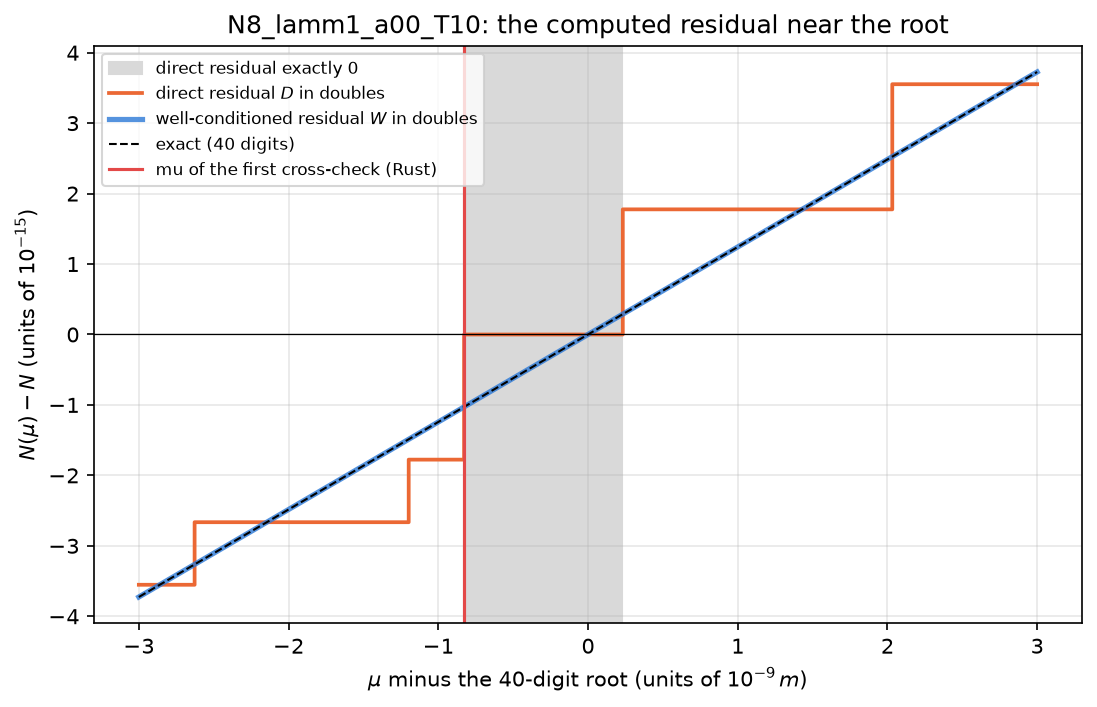

Figure 16c.2 saved as Revision/textbook/figures/16c_2_residual_staircase.png


In [6]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))
scale_mu, scale_r = 1e-9, 1e-15  # plot units: 1e-9 m and 1e-15 particles
ax.axvspan(zero.min() / scale_mu, zero.max() / scale_mu, color="0.85",
           label="direct residual exactly 0")
ax.step(shifts / scale_mu, D / scale_r, where="mid", color=PALETTE[1], lw=1.8,
        label="direct residual $D$ in doubles")
ax.plot(shifts / scale_mu, W / scale_r, color=PALETTE[0], lw=2.5, alpha=0.8,
        label="well-conditioned residual $W$ in doubles")
ax.plot(shifts / scale_mu, X / scale_r, "k--", lw=1.0, label="exact (40 digits)")
ax.axvline((MU_OLD_RUST - mu_star) / scale_mu, color=PALETTE[7], lw=1.5,
           label="mu of the first cross-check (Rust)")
ax.axhline(0.0, color="k", lw=0.6)
ax.set_xlabel("$\\mu$ minus the 40-digit root (units of $10^{-9}\\,m$)")
ax.set_ylabel("$N(\\mu) - N$ (units of $10^{-15}$)")
ax.set_title("N8_lamm1_a00_T10: the computed residual near the root")
ax.legend(fontsize=8, loc="upper left")
save_figure(fig, "residual_staircase",
            "The residual $N(\\mu) - N$ of the Mermin condition of the state "
            "N8_lamm1_a00_T10 (Rust levels) within $3 \\times 10^{-9}\\,m$ of the "
            "40-digit root, horizontal axis in units of $10^{-9}\\,m$, vertical axis "
            "in units of $10^{-15}$ particles. Added up directly in ordinary computer "
            "numbers (orange) the sum near 8 can only change in steps of $2^{-50}$ "
            "or $2^{-49}$, so the residual is a staircase that is exactly zero on an "
            "interval about $10^{-9}$ wide (grey); the faulty $\\mu$ of the first "
            "cross-check (red) is the left end of that interval. The "
            "well-conditioned form (blue) follows the exact line (dashed) and "
            "crosses zero at the root.")

## 8. Bisection on the two forms: the faulty value, and the repair

**Bisection.** If a function is increasing, negative at $lo$ and not negative at
$hi$, its root lies between them. Take the midpoint $mid$; if the function is
negative there, the root lies above it ($lo = mid$), otherwise at or below it
($hi = mid$). Every step halves the interval. In doubles one stops when $lo$ and
$hi$ are neighbouring doubles (the midpoint can no longer be different from both).
This is how both solvers searched for $\mu$, starting from an interval that contains
every level.

**The well-conditioned form, line by line.** Split the sum into the levels below
$\mu$ ($x_i < 0$) and the levels above ($x_i \ge 0$).

- $f(x) + f(-x) = \dfrac{1}{1 + e^x} + \dfrac{1}{1 + e^{-x}}
  = \dfrac{1}{1 + e^x} + \dfrac{e^x}{e^x + 1} = 1$ (multiply the second fraction by
  $e^x/e^x$), so $f(x) = 1 - f(-x)$.
- Below $\mu$ write each occupation as $1 - f(-x_i)$:
  $\sum_i g_i f(x_i) - N = \sum_{below} g_i\,(1 - f(-x_i)) + \sum_{above} g_i\,f(x_i)
  - N$.
- Collect the ones:
  $W(\mu) = \Big(\sum_{below} g_i - N\Big) - \sum_{below} g_i\,f(-x_i)
  + \sum_{above} g_i\,f(x_i)$.
- The first bracket is a sum of whole numbers, which doubles add exactly. The second
  sum is $H_{th}$, the thermal holes, and the third is $P$, the thermal particles; both
  are sums of small positive numbers, each computed with a relative error of about
  $10^{-16}$. Near the root $W$ is small and is known to about $10^{-16}$ of the size
  of $H_{th}$ and $P$ (here $6\times10^{-9}$), instead of $10^{-16}$ of $N = 8$.

The value is the same as before (it is an exact rewriting); only the rounding is
different. The next cell runs bisection on both forms with the Rust levels, starting
from the interval the reference uses, and records every midpoint.

In [7]:
def bisection(residual, lo, hi):
    """Bisection for the root of an increasing function with residual(lo) < 0 and
    residual(hi) >= 0, down to neighbouring doubles; returns (root, all midpoints)."""
    midpoints = []
    while True:
        mid = 0.5 * (lo + hi)
        if mid <= lo or mid >= hi:  # lo and hi are neighbouring doubles: done
            break
        midpoints.append(mid)
        if residual(mid) < 0.0:
            lo = mid  # the root lies above mid
        else:
            hi = mid  # the root lies at or below mid
    return 0.5 * (lo + hi), midpoints


def bracket(eps, T):
    """The starting interval of the reference: every level, 60 T and 1 m around."""
    return float(eps.min()) - 60.0 * T - 1.0, float(eps.max()) + 60.0 * T + 1.0


MU_DIRECT, PATH_DIRECT = bisection(
    lambda mu: direct_residual(mu, eps_r, g_r, 8.0, 0.01), *bracket(eps_r, 0.01))
MU_WELL, PATH_WELL = bisection(
    lambda mu: K.mermin_residual(eps_r, g_r, 8.0, 0.01, mu), *bracket(eps_r, 0.01))
_, mu_ks_fd = K.mermin(eps_r, g_r, 8.0, 0.01)  # the reference's own function
say(f"bisection, direct sum:      mu = {MU_DIRECT!r} after {len(PATH_DIRECT)} "
    f"halvings; minus root {float(MU_DIRECT - ROOT_R):+.3e}")
say(f"bisection, well-conditioned: mu = {MU_WELL!r} after {len(PATH_WELL)} "
    f"halvings; minus root {float(MU_WELL - ROOT_R):+.3e}")
say(f"recorded mu of the first cross-check (Rust): {MU_OLD_RUST!r}; committed "
    f"repaired Rust mu: {S['mu_rust']!r}")
report("direct-sum bisection minus the 40-digit root",
       f"{float(MU_DIRECT - ROOT_R):.4e}", "m")
check(abs(MU_DIRECT - MU_OLD_RUST) <= 5e-17,
      "bisection on the direct sum gives the recorded faulty mu (all 16 digits)",
      record=f"{KS}/checker/README.md, History 1 (Rust mu 0.2100104489071649)")
check(MU_WELL == mu_ks_fd and abs(MU_WELL - ROOT_R) < 1e-16,
      "bisection on the well-conditioned form (ks_fd.mermin) finds the root to 1e-16")
check(abs(S["mu_rust"] - MU_WELL) < 1e-16,
      "the committed repaired Rust mu equals the well-conditioned root",
      record=f"{KS}/results/thermo/thermodynamics.csv, state {STATE}")
mu_direct_ref, _ = bisection(
    lambda mu: direct_residual(mu, S["eps_ref"], S["g_ref"], 8.0, 0.01),
    *bracket(S["eps_ref"], 0.01))
say(f"the direct sum on the reference levels misses their root by "
    f"{float(mu_direct_ref - ROOT_F):+.3e}")

bisection, direct sum:      mu = 0.21001044890716491 after 57 halvings; minus root
    -8.267e-10
bisection, well-conditioned: mu = 0.21001044973390365 after 57 halvings; minus root
    +2.568e-18
recorded mu of the first cross-check (Rust): 0.2100104489071649; committed repaired Rust
    mu: 0.2100104497339036
RESULT direct-sum bisection minus the 40-digit root = -8.2674e-10 m
PASS bisection on the direct sum gives the recorded faulty mu (all 16 digits)
     reproduces Revision/kohn_sham/checker/README.md, History 1 (Rust mu
    0.2100104489071649)
PASS bisection on the well-conditioned form (ks_fd.mermin) finds the root to 1e-16
PASS the committed repaired Rust mu equals the well-conditioned root
     reproduces Revision/kohn_sham/results/thermo/thermodynamics.csv, state
    N8_lamm1_a00_T10
the direct sum on the reference levels misses their root by -8.271e-10


The direct sum also misses on the reference levels, by almost the same amount
(printed above): their levels agree with the Rust levels to about $10^{-12}$, so
their staircase has a zero interval at almost the same place, and bisection again
stops at its left end. (The reference's own first complete run missed by
$1.15\times10^{-9}$; it computed $\mu$ on each of its three grids and then combined
them, so that number is not the same computation and is not reproduced here.)

The next figure follows the three searches step by step: the distance of each guess
from the 40-digit root, on a logarithmic axis. Bisection halves the distance at every
step (a straight line on this axis); on the direct sum it stops improving near
$10^{-9}$, because from there on it only explores the zero interval of the
staircase; on the well-conditioned form it goes on down to the spacing of the doubles
near $\mu$, about $3\times10^{-17}$. Newton's method with 40 digits needs only a few
steps, and the number of correct digits roughly doubles at each.

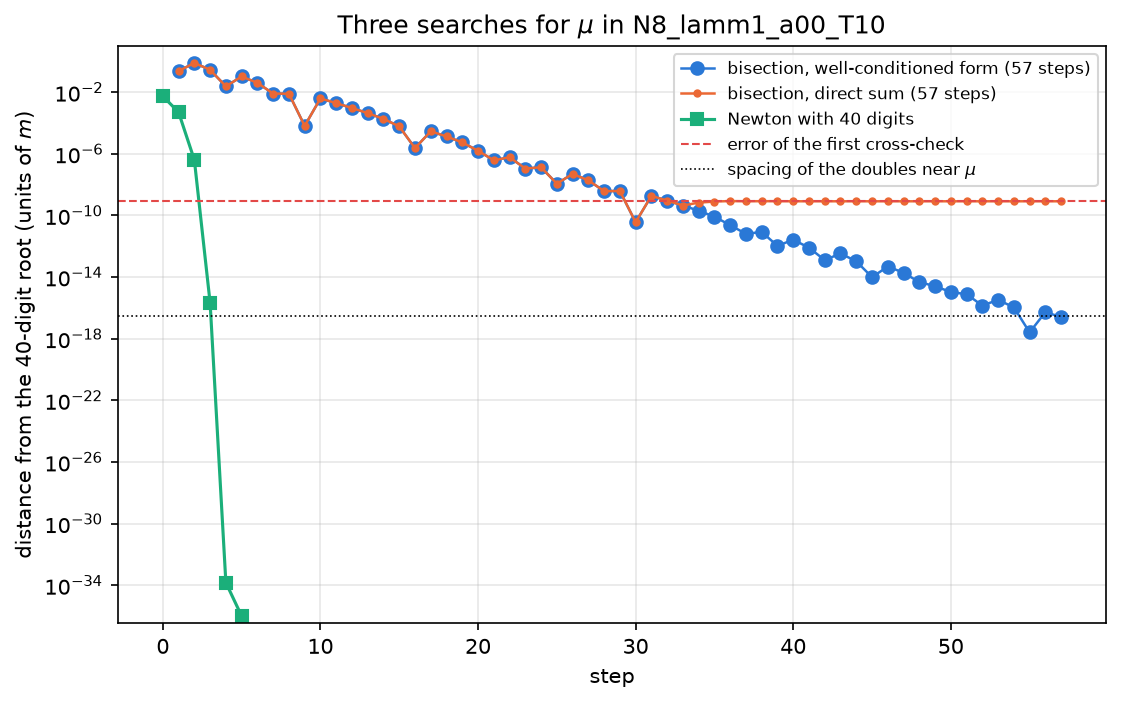

Figure 16c.3 saved as Revision/textbook/figures/16c_3_convergence_paths.png
PASS the direct bisection stalls above 5e-10; Newton reaches 1e-32 in 5 steps


In [8]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))
floor = 1e-36  # distances that are exactly zero are drawn here
for colour, path, label, size in (
        (PALETTE[0], PATH_WELL, "bisection, well-conditioned form", 6),
        (PALETTE[1], PATH_DIRECT, "bisection, direct sum", 3)):  # drawn on top
    distance = [max(float(abs(mp.mpf(m) - ROOT_R)), floor) for m in path]
    ax.semilogy(range(1, len(path) + 1), distance, "o-", color=colour, ms=size,
                lw=1.2, label=f"{label} ({len(path)} steps)")
newton = [max(float(abs(m - ROOT_R)), floor) for m in NEWTON_PATH]
ax.semilogy(range(len(newton)), newton, "s-", color=PALETTE[2], ms=6, lw=1.5,
            label="Newton with 40 digits")
ax.axhline(abs(MU_OLD_RUST - float(ROOT_R)), color=PALETTE[7], lw=1.0, ls="--",
           label="error of the first cross-check")
ax.axhline(math.ulp(mu_star), color="k", lw=0.8, ls=":",
           label="spacing of the doubles near $\\mu$")
ax.set_ylim(floor / 3.0, 10.0)
ax.set_xlabel("step")
ax.set_ylabel("distance from the 40-digit root (units of $m$)")
ax.set_title("Three searches for $\\mu$ in N8_lamm1_a00_T10")
ax.legend(fontsize=8, loc="upper right")
save_figure(fig, "convergence_paths",
            "The distance of each guess for $\\mu$ from the 40-digit root, units "
            "of $m$, logarithmic, against the step number, for the state "
            "N8_lamm1_a00_T10 with the Rust levels. Bisection halves the distance at "
            "every step; on the direct sum (orange) it stalls at $8.3 \\times "
            "10^{-10}$, the error of the first cross-check (red dashed), because "
            "the computed sum is zero on a whole interval; on the well-conditioned "
            "form (blue) it reaches the spacing of the doubles (dotted). Newton's "
            "method with 40 digits (green) doubles the number of correct digits at "
            "each step; zero distances are drawn at $10^{-36}$.")
check(min(float(abs(mp.mpf(m) - ROOT_R)) for m in PATH_DIRECT[-20:]) > 5e-10
      and float(abs(NEWTON_PATH[-2] - ROOT_R)) < 1e-32 and len(NEWTON_PATH) <= 7,
      "the direct bisection stalls above 5e-10; Newton reaches 1e-32 in 5 steps")

## 9. The rounding bounds: predicting the error

How large can the error of a computed root be? Line by line:

- Suppose the computed residual is off by $\delta R$ (rounding). Near the root the
  residual is the tangent line $N'(\mu - \mu_{root})$, so the computed root sits
  where $N'(\mu - \mu_{root}) + \delta R = 0$, that is $\mu - \mu_{root} =
  -\delta R/N'$.
- Adding $n$ numbers in doubles makes an error of at most about $n\,\epsilon_{mach}$
  times the size of the numbers. For the direct sum the numbers are the
  occupations, of total size $N$, so $|\delta R| \lesssim n\,\epsilon_{mach} N$ and
  $|\mu - \mu_{root}| \lesssim n\,\epsilon_{mach} N / N'$.
- For the well-conditioned form the numbers are $H_{th}$, $P$ and the whole number
  $d = N - \sum_{below} g$ (zero at the root of this state), so $N$ is replaced by
  $P + H_{th} + |d|$.

The Rust solver's documentation (file `solver/src/mermin.rs`) states the complete
bounds, with generous constants. Besides the summation they count the rounding of
the arguments $x_i = (\varepsilon_i - \mu)/T$ (the term with
$\langle|\varepsilon - \mu|\rangle$), the logarithms of the degeneracies and a few
constants (the term with $T$), the returned double (the term with $|\mu|$), and, for
the well-conditioned form, the logarithms with which the solver balances the two
sides $A = P + d_-$ and $B = H_{th} + d_+$ ($d_\pm = \max(\pm d, 0)$; at the root
$A = B$):
$$B_{direct} = \epsilon_{mach}\Big[(n + 2)\,\frac{N}{N'} + 3\,\langle|\varepsilon
- \mu|\rangle + T(\ln g_{max} + 3) + 2|\mu|\Big],$$
$$B_{well} = \epsilon_{mach}\Big[(n + 2 + \Lambda)\,\frac{P + H_{th} + |d|}{N'}
+ 3\,\langle|\varepsilon - \mu|\rangle + T(\ln g_{max} + 3) + 2|\mu|\Big],$$
where $n$ is the number of levels, $g_{max}$ the largest degeneracy,
$\Lambda = \max(|\ln A|, |\ln B|)$, and $\langle\cdot\rangle$ the average weighted with
$g f(1 - f)$. The next cell evaluates both at the root and compares them with the
entry of this state in the Rust solver's 40-digit report `ks-rust-mermin-roots.json`
(which prints 4 digits).

In [9]:
def rounding_bounds(eps, g, N, T, mu):
    """dN/dmu, the bound of the direct sum and the bound of the well-conditioned form
    at mu (the formulas of solver/src/mermin.rs), and P, H_th, d."""
    x = (eps - mu) / T
    f_plus, f_minus = K.fermi(x), K.fermi(-x)  # f(x) and 1 - f(x) = f(-x)
    weight = g * f_plus * f_minus  # g f (1 - f): how strongly a level reacts to mu
    slope = float(np.sum(weight)) / T  # dN/dmu
    mean_distance = float(np.sum(weight * np.abs(eps - mu)) / np.sum(weight))
    below = x < 0.0
    particles = float(np.sum(g[~below] * f_plus[~below]))  # P
    holes = float(np.sum(g[below] * f_minus[below]))  # H_th
    d = N - float(np.sum(g[below]))  # a whole number
    n = len(eps)
    big_l = max(abs(math.log(particles + max(-d, 0.0))),  # |ln A|
                abs(math.log(holes + max(d, 0.0))))  # |ln B|
    common = EPS_MACH * (3.0 * mean_distance + T * (math.log(float(np.max(g))) + 3.0)
                         + 2.0 * abs(mu))
    direct = EPS_MACH * (n + 2) * N / slope + common
    well = EPS_MACH * (n + 2 + big_l) * (particles + holes + abs(d)) / slope + common
    return {"slope": slope, "direct": direct, "well": well, "P": particles,
            "H_th": holes, "d": d, "n": n, "Lambda": big_l}


MERMIN_REPORT = read_json(f"{KS}/reports/ks-rust-mermin-roots.json")
RECORD = {s["id"]: s for s in MERMIN_REPORT["states"]}
b = rounding_bounds(eps_r, g_r, 8.0, 0.01, mu_star)
rec = RECORD[STATE]
say(f"n = {b['n']} levels; P = {b['P']:.6e}, H_th = {b['H_th']:.6e}, d = {b['d']:.0f}, "
    f"Lambda = {b['Lambda']:.3f}; dN/dmu = {b['slope']:.6e} (record {rec['dN_dmu']})")
say(f"B_direct = {b['direct']:.4e} (record {rec['boundDirectCount']}); B_well = "
    f"{b['well']:.4e} (record {rec['boundWellConditioned']})")
one_step = EPS_MACH * 8.0 / b["slope"]  # one rounding of size eps_mach N, as mu
say(f"one rounding of size eps_mach N moves the root by {one_step:.3e}; the error "
    f"of the first cross-check is {DIFF_OLD / one_step:.2f} of that")
check(abs(b["slope"] / float(rec["dN_dmu"]) - 1) < 1e-5
      and abs(b["direct"] / float(rec["boundDirectCount"]) - 1) < 1e-3
      and abs(b["well"] / float(rec["boundWellConditioned"]) - 1) < 1e-3,
      "dN/dmu and both rounding bounds reproduce the Rust 40-digit report",
      record=f"{KS}/reports/ks-rust-mermin-roots.json, state {STATE}")
check(abs(MU_OLD_RUST - float(ROOT_R)) <= b["direct"]
      and abs(S["mu_rust"] - float(ROOT_R)) <= b["well"] + 1e-16,
      "the old error lies within B_direct, the repaired mu within B_well")

n = 7 levels; P = 6.210359e-09, H_th = 6.210359e-09, d = 0, Lambda = 18.897; dN/dmu =
    1.242072e-06 (record 1.242072e-06)
B_direct = 1.2871e-08 (record 1.287e-08); B_well = 3.1539e-16 (record 3.154e-16)
one rounding of size eps_mach N moves the root by 1.430e-09; the error of the first
    cross-check is 0.58 of that
PASS dN/dmu and both rounding bounds reproduce the Rust 40-digit report
     reproduces Revision/kohn_sham/reports/ks-rust-mermin-roots.json, state
    N8_lamm1_a00_T10
PASS the old error lies within B_direct, the repaired mu within B_well


So the error of the first cross-check was no accident: it has exactly the size that
the rounding of the direct sum allows. $8.27\times10^{-10}$ is about 0.6 of the shift
that a single rounding of size $\epsilon_{mach} N$ causes, and far inside
$B_{direct} \approx 1.3\times10^{-8}$. The well-conditioned form shrinks the bound
to about $3\times10^{-16}$ (printed above), a factor of about $4\times10^{7}$.

## 10. All 45 thermal states with eight particles

Is N8_lamm1_a00_T10 special? The next cell repeats everything for the 45 thermal
states with $N = 8$ (3 couplings, 5 slices, 3 temperatures), for the levels of both
solvers: the 40-digit root (90 roots; this takes about half a minute), $dN/d\mu$ and
the two bounds, the bisection on the direct sum and on the well-conditioned form,
and the cross-check's comparisons. It reproduces four records:

- the 40-digit roots, $dN/d\mu$ and the two bounds of `ks-rust-mermin-roots.json`
  (the level files keep 16 digits, so the roots agree to about $10^{-17}$, not
  $10^{-35}$);
- the rows `<state> mu_high_precision` of the cross-check table: both 40-digit roots,
  the tolerance with $U_{ref}$ = the largest level uncertainty of the reference and
  $U_{Rust} = \tfrac{16}{15}\times$ the largest canonical-minus-refined level
  difference, and the ratio;
- the rows `<state> mu` (check `thermo_state_functions`): the two committed values of
  $\mu$ with $U_{ref}$ of the reference's $\mu$ and $U_{Rust} = \tfrac{16}{15}|\mu_
  {canonical} - \mu_{refined}|$;
- the check `thermo_mu_rounding_diagnostic`: each committed $\mu$ lies within
  $n\,\epsilon_{mach} N/N'$ of the root on its own levels (plus $3U$ for the
  reference, whose $\mu$ is a combination of three grids).

In [10]:
TABLE = {r["case"]: r for r in read_csv(f"{KS}/reports/ks-crosscheck-table.csv")}


def tolerance(x_ref, u_ref, u_rust):
    """The tolerance rule of the cross-check for single numbers."""
    return 3.0 * (u_ref + u_rust) + 1e-12 * max(1.0, abs(x_ref))


ROWS = []  # one dictionary per state
for sid in sorted(s for s in REFINEMENT if s.startswith("N8_")):
    s = state_data(sid)
    N, T = s["N"], s["T"]
    root_r, _, _ = mermin_root_40(s["eps_rust"], s["g_rust"], N, T, s["mu_rust"])
    root_f, _, _ = mermin_root_40(s["eps_ref"], s["g_ref"], N, T, s["mu_ref"])
    r = {"id": sid, "N": N, "T": T, "root_r": root_r, "root_f": root_f,
         "b_r": rounding_bounds(s["eps_rust"], s["g_rust"], N, T, float(root_r)),
         "b_f": rounding_bounds(s["eps_ref"], s["g_ref"], N, T, float(root_f))}
    for side in ("r", "f"):  # the two bisections on each solver's levels
        e, gg = (s["eps_rust"], s["g_rust"]) if side == "r" else (s["eps_ref"],
                                                                    s["g_ref"])
        root = float(r["root_" + side])
        r["direct_" + side] = bisection(
            lambda mu: direct_residual(mu, e, gg, N, T), *bracket(e, T))[0] - root
        r["well_" + side] = bisection(
            lambda mu: K.mermin_residual(e, gg, N, T, mu), *bracket(e, T))[0] - root
    r["committed_r"] = float(mp.mpf(s["mu_rust"]) - root_r)
    r["committed_f"] = float(mp.mpf(s["mu_ref"]) - root_f)
    r["U_mu_ref"] = s["U_mu_ref"]
    u_lev_rust = 16.0 / 15.0 * REFINEMENT[sid]["levels"]["max_abs_diff"]
    u_mu_rust = 16.0 / 15.0 * REFINEMENT[sid]["scalars"]["mu"]["abs_diff"]
    tol_hp = tolerance(float(root_f), s["U_levels_ref"], u_lev_rust)
    tol_mu = tolerance(s["mu_ref"], s["U_mu_ref"], u_mu_rust)
    r["ratio_hp"] = float(abs(root_r - root_f)) / tol_hp
    r["ratio_mu"] = abs(s["mu_rust"] - s["mu_ref"]) / tol_mu
    r["tol_hp"], r["tol_mu"] = tol_hp, tol_mu
    r["n_r"], r["n_f"] = len(s["eps_rust"]), len(s["eps_ref"])
    ROWS.append(r)

print("the nine states with the largest direct-sum bound (Rust levels):")
print("state                 n   dN/dmu     B_direct   direct error  B_well")
for r in sorted(ROWS, key=lambda r: -r["b_r"]["direct"])[:9]:
    print(f"{r['id']:20s} {r['n_r']:3d}  {r['b_r']['slope']:.3e}  "
          f"{r['b_r']['direct']:.3e}  {r['direct_r']:+.3e}    {r['b_r']['well']:.3e}")

the nine states with the largest direct-sum bound (Rust levels):
state                 n   dN/dmu     B_direct   direct error  B_well
N8_lamp1_a00_T10       7  1.216e-06  1.315e-08  +6.959e-11    3.155e-16
N8_lamm1_a00_T10       7  1.242e-06  1.287e-08  -8.267e-10    3.154e-16
N8_lam0_a00_T10        5  1.229e-06  1.012e-08  +2.722e-10    3.095e-16
N8_lamp1_a05_T10      13  3.302e-03  8.069e-12  -2.050e-13    2.239e-16
N8_lamm1_a05_T10      13  3.359e-03  7.932e-12  -1.527e-15    2.239e-16
N8_lam0_a05_T10        8  3.329e-03  5.337e-12  -3.366e-13    2.123e-16
N8_lamp1_a00_T20      11  2.903e-02  7.957e-13  -2.803e-15    3.628e-16
N8_lamm1_a00_T20      11  2.934e-02  7.872e-13  -1.768e-14    3.627e-16
N8_lam0_a00_T20        8  2.919e-02  6.089e-13  +1.621e-14    3.484e-16


The next cell makes the checks against the four records and against the bounds.

In [11]:
worst = {"root": 0.0, "slope": 0.0, "bounds": 0.0, "hp": 0.0, "tol": 0.0,
         "ratio": 0.0}
for r in ROWS:
    rec = RECORD[r["id"]]
    worst["root"] = max(worst["root"], float(abs(r["root_r"] - mp.mpf(rec["root40"]))))
    worst["slope"] = max(worst["slope"],
                         abs(r["b_r"]["slope"] / float(rec["dN_dmu"]) - 1))
    worst["bounds"] = max(worst["bounds"],
                          abs(r["b_r"]["direct"] / float(rec["boundDirectCount"]) - 1),
                          abs(r["b_r"]["well"] / float(rec["boundWellConditioned"])
                              - 1))
    hp, mu_row = TABLE[f"{r['id']} mu_high_precision"], TABLE[f"{r['id']} mu"]
    worst["hp"] = max(worst["hp"], abs(float(r["root_r"]) - float(hp["rust"])),
                      abs(float(r["root_f"]) - float(hp["reference"])))
    worst["tol"] = max(worst["tol"], abs(r["tol_hp"] / float(hp["tolerance"]) - 1),
                       abs(r["tol_mu"] / float(mu_row["tolerance"]) - 1))
    worst["ratio"] = max(worst["ratio"], abs(r["ratio_hp"] - float(hp["ratio"])),
                         abs(r["ratio_mu"] - float(mu_row["ratio"])))
say("largest differences from the records: " + ", ".join(
    f"{k} {v:.1e}" for k, v in worst.items()))
check(worst["root"] < 1e-16,
      "the 45 roots on the Rust levels reproduce root40 (to the 16-digit levels)",
      record=f"{KS}/reports/ks-rust-mermin-roots.json, states (root40)")
check(worst["slope"] < 1e-5 and worst["bounds"] < 1e-3,
      "dN/dmu and both bounds of all 45 states reproduce the Rust report",
      record=f"{KS}/reports/ks-rust-mermin-roots.json, states (bounds)")
check(worst["hp"] < 2e-16 and worst["tol"] < 1e-3 and worst["ratio"] <= 1e-4,
      "both 40-digit roots, tolerances and ratios reproduce 90 table rows",
      record=f"{KS}/reports/ks-crosscheck-table.csv, rows mu, mu_high_precision")
check(all(r["ratio_hp"] <= 1.0 and r["ratio_mu"] <= 1.0 for r in ROWS),
      "after the repair every mu comparison of the 45 states passes",
      record=f"{KS}/reports/ks-crosscheck.json, check thermo_state_functions")
diag_r = [abs(r["committed_r"]) / (r["n_r"] * EPS_MACH * r["N"] / r["b_r"]["slope"])
          for r in ROWS]
diag_f = [abs(r["committed_f"]) / (r["n_f"] * EPS_MACH * r["N"] / r["b_f"]["slope"]
                                   + 3.0 * r["U_mu_ref"]) for r in ROWS]
say(f"committed mu minus root, as a fraction of the diagnostic bound: Rust at most "
    f"{max(diag_r):.1e}, reference at most {max(diag_f):.1e}")
check(max(diag_r) <= 1.0 and max(diag_f) <= 1.0,
      "both solvers' committed mu lie within the rounding diagnostic",
      record=f"{KS}/reports/ks-crosscheck.json, check thermo_mu_rounding_diagnostic")
check(all(abs(r["direct_" + s]) <= r["b_" + s]["direct"]
          and abs(r["well_" + s]) <= r["b_" + s]["well"] for r in ROWS
          for s in ("r", "f")),
      "in all 90 level sets each bisection lies within its own bound")
big = sorted(ROWS, key=lambda r: -abs(r["direct_r"]))[:3]
say("largest direct-sum errors: " + ", ".join(
    f"{r['id']} {r['direct_r']:+.2e}" for r in big))
check({r["id"] for r in big} == {"N8_lam0_a00_T10", "N8_lamm1_a00_T10",
                                 "N8_lamp1_a00_T10"},
      "the direct sum fails worst in the three states with the largest gap/T")

largest differences from the records: root 2.8e-17, slope 4.5e-07, bounds 4.2e-04, hp
    5.6e-17, tol 3.9e-04, ratio 5.0e-05
PASS the 45 roots on the Rust levels reproduce root40 (to the 16-digit levels)
     reproduces Revision/kohn_sham/reports/ks-rust-mermin-roots.json, states (root40)
PASS dN/dmu and both bounds of all 45 states reproduce the Rust report
     reproduces Revision/kohn_sham/reports/ks-rust-mermin-roots.json, states (bounds)
PASS both 40-digit roots, tolerances and ratios reproduce 90 table rows
     reproduces Revision/kohn_sham/reports/ks-crosscheck-table.csv, rows mu,
    mu_high_precision
PASS after the repair every mu comparison of the 45 states passes
     reproduces Revision/kohn_sham/reports/ks-crosscheck.json, check
    thermo_state_functions
committed mu minus root, as a fraction of the diagnostic bound: Rust at most 1.3e-02,
    reference at most 1.4e-05
PASS both solvers' committed mu lie within the rounding diagnostic
     reproduces Revision/kohn_sham/r

The next figure collects the errors of all 180 computed roots (45 states, two
solvers' levels, two methods; plus the committed values) against the
conditioning scale $\epsilon_{mach} N/N'$, the shift of the root caused by one
rounding of size $\epsilon_{mach} N$. The direct sum (orange and red) scatters
below the line of slope 1, reaching it where the conditioning is worst; the
well-conditioned form and the committed values (blue and green) stay near
$10^{-17}$ whatever the conditioning. Errors that are exactly zero are drawn at
$10^{-19}$.

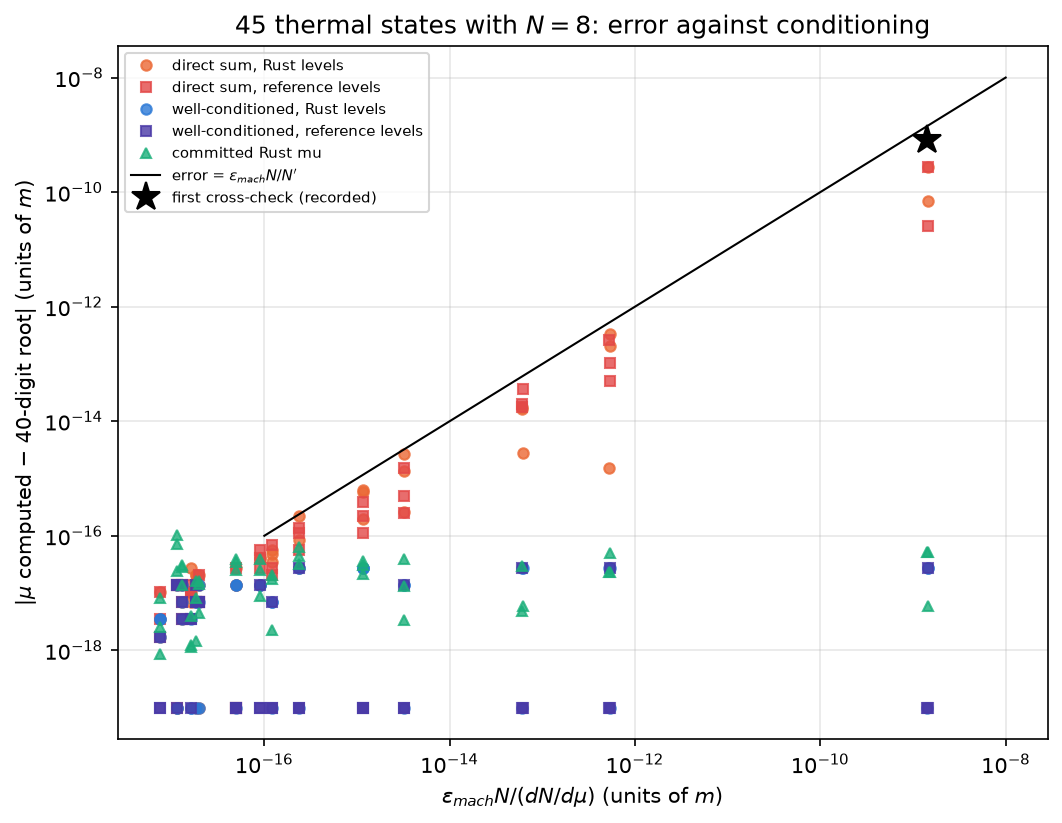

Figure 16c.4 saved as Revision/textbook/figures/16c_4_errors_versus_bound.png


In [12]:
scale = np.array([EPS_MACH * r["N"] / r["b_r"]["slope"] for r in ROWS])
scale_f = np.array([EPS_MACH * r["N"] / r["b_f"]["slope"] for r in ROWS])
fig, ax = plt.subplots(figsize=(8.0, 6.0))
low = 1e-19  # exact zeros are drawn here
series = [(scale, "direct_r", "o", PALETTE[1], "direct sum, Rust levels"),
          (scale_f, "direct_f", "s", PALETTE[7], "direct sum, reference levels"),
          (scale, "well_r", "o", PALETTE[0], "well-conditioned, Rust levels"),
          (scale_f, "well_f", "s", PALETTE[6], "well-conditioned, reference levels"),
          (scale, "committed_r", "^", PALETTE[2], "committed Rust mu")]
for xs, key, marker, colour, label in series:
    ys = np.maximum([abs(r[key]) for r in ROWS], low)
    ax.loglog(xs, ys, marker, color=colour, ms=5, alpha=0.8, label=label)
line = np.array([1e-16, 1e-8])
ax.loglog(line, line, "k-", lw=1.0, label="error = $\\epsilon_{mach} N / N'$")
i_old = [r["id"] for r in ROWS].index(STATE)
ax.loglog([scale[i_old]], [DIFF_OLD], "*", color="k", ms=14,
          label="first cross-check (recorded)")
ax.set_xlabel("$\\epsilon_{mach} N / (dN/d\\mu)$ (units of $m$)")
ax.set_ylabel("$|\\mu$ computed $-$ 40-digit root$|$ (units of $m$)")
ax.set_title("45 thermal states with $N = 8$: error against conditioning")
ax.legend(fontsize=7, loc="upper left")
save_figure(fig, "errors_versus_bound",
            "Errors of the computed chemical potential, in units of $m$, against "
            "the conditioning scale $\\epsilon_{mach} N/(dN/d\\mu)$ for the 45 "
            "thermal states with $N = 8$, both axes logarithmic. Bisection on the "
            "direct sum (orange: Rust levels, red: reference levels) has errors "
            "that grow with the conditioning scale and approach the line of slope 1 "
            "in the worst states; the star is the recorded error of the first "
            "cross-check. The well-conditioned form (blue, purple) and the "
            "committed repaired Rust values (green) stay near $10^{-17}$ for every "
            "state; exact zeros are drawn at $10^{-19}$.")

Where in the canonical matrix is the direct sum dangerous? The next figure shows
$B_{direct}$ of the 45 states as three maps (one per coupling), with the slice
$a_{4,0}$ downwards and the temperature across; the colour and the number in each
square give $\log_{10} B_{direct}$. At $a_{4,0} = 0$ and $T = 0.01$ the gap is 43
times $T$ and the bound is $10^{-8}$. Along the history 3-space inflates and the
extra times deflate: the 3-momenta are redshifted by $e^{-a_{4,0}}$, the levels above
the gap move down, the gap shrinks, $dN/d\mu$ grows, and the bound falls towards
$10^{-15}$.

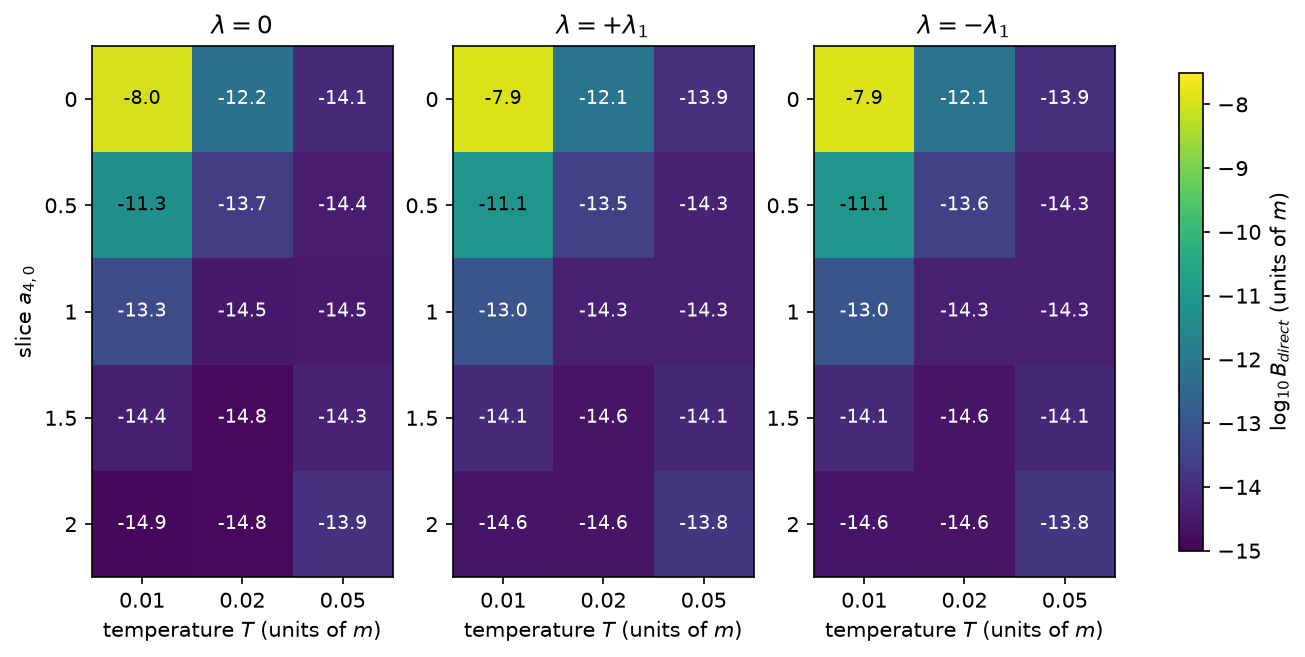

Figure 16c.5 saved as Revision/textbook/figures/16c_5_conditioning_map.png
PASS the bound is largest at a4,0 = 0, T = 0.01 and falls along the history


In [13]:
tags = [("lam0", "$\\lambda = 0$"), ("lamp1", "$\\lambda = +\\lambda_1$"),
        ("lamm1", "$\\lambda = -\\lambda_1$")]
slices, temps = ["a00", "a05", "a10", "a15", "a20"], ["T10", "T20", "T50"]
by_id = {r["id"]: r for r in ROWS}
fig, axes = plt.subplots(1, 3, figsize=(11.0, 4.6))
for ax, (tag, title) in zip(axes, tags):
    grid = np.array([[math.log10(by_id[f"N8_{tag}_{a}_{t}"]["b_r"]["direct"])
                      for t in temps] for a in slices])
    image = ax.imshow(grid, cmap="viridis", vmin=-15.0, vmax=-7.5, aspect="auto")
    ax.grid(False)  # no grid lines across the coloured squares
    for i in range(5):
        for j in range(3):
            ax.text(j, i, f"{grid[i, j]:.1f}", ha="center", va="center",
                    color="w" if grid[i, j] < -11.5 else "k", fontsize=9)
    ax.set_xticks(range(3))
    ax.set_xticklabels(["0.01", "0.02", "0.05"])
    ax.set_yticks(range(5))
    ax.set_yticklabels(["0", "0.5", "1", "1.5", "2"])
    ax.set_xlabel("temperature $T$ (units of $m$)")
    ax.set_title(title)
axes[0].set_ylabel("slice $a_{4,0}$")
fig.colorbar(image, ax=axes, shrink=0.9, label="$\\log_{10} B_{direct}$ (units of $m$)")
save_figure(fig, "conditioning_map",
            "The rounding bound $B_{direct}$ of the direct sum, as $\\log_{10}$ of "
            "its value in units of $m$, for the 45 thermal states with $N = 8$ (Rust "
            "levels): one map per coupling, the slice $a_{4,0}$ of the deflating "
            "history downwards, the temperature across. The direct sum is dangerous "
            "only at low temperature early in the history, where the gap is 43 "
            "times $T$ and the bound reaches $10^{-8}$; later the redshift of the "
            "3-momenta closes the gap and the bound falls to about $10^{-15}$.")
check(max(by_id[f"N8_{t}_a00_T10"]["b_r"]["direct"] for t, _ in tags)
      == max(r["b_r"]["direct"] for r in ROWS)
      and all(by_id[f"N8_{t}_a00_T10"]["b_r"]["direct"]
              > 100.0 * by_id[f"N8_{t}_a10_T10"]["b_r"]["direct"] for t, _ in tags),
      "the bound is largest at a4,0 = 0, T = 0.01 and falls along the history")

## 11. What the tolerance rule did

The last figure is the cross-check's view. For each of the 45 states it shows the
ratio of the $\mu$ comparison (`thermo_state_functions`, circles) and of the
40-digit comparison (`thermo_mu_high_precision`, squares), both computed above, and
the ratio of the failed first comparison, $8.27\times10^{-10}/7.97\times10^{-12}$
(red star). The rule was fixed before the comparison and was not changed afterwards:
the failure was explained (the 40-digit roots), the program was repaired, and the
same rule then passed.

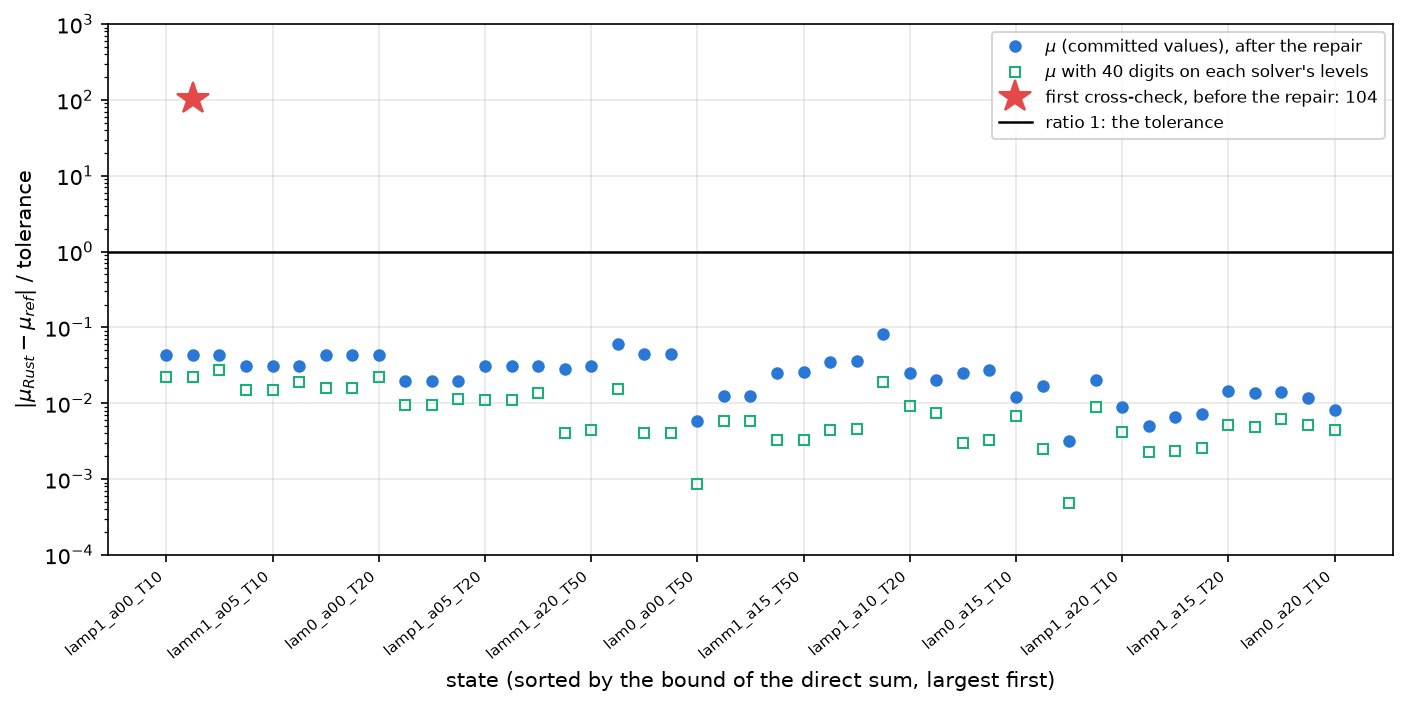

Figure 16c.6 saved as Revision/textbook/figures/16c_6_crosscheck_ratios.png
first comparison: ratio 103.8. After the repair, over these 45 states: mu at most 0.0825,
    40-digit roots at most 0.0270 (the report, over all 135 states: 40-digit roots at
    most 0.05)
PASS the first comparison failed the rule; after the repair all ratios are small
     reproduces Revision/kohn_sham/reports/ks-crosscheck.json, check
    thermo_mu_high_precision


In [14]:
order = sorted(range(len(ROWS)), key=lambda i: -ROWS[i]["b_r"]["direct"])
ratio_old = DIFF_OLD / TOL_OLD  # the ratio of the first, failed comparison
fig, ax = plt.subplots(figsize=(9.5, 4.8))
positions = np.arange(len(order))
ax.semilogy(positions, [ROWS[i]["ratio_mu"] for i in order], "o", color=PALETTE[0],
            ms=5, label="$\\mu$ (committed values), after the repair")
ax.semilogy(positions, [ROWS[i]["ratio_hp"] for i in order], "s", color=PALETTE[2],
            ms=5, mfc="none", label="$\\mu$ with 40 digits on each solver's levels")
k_old = order.index([r["id"] for r in ROWS].index(STATE))
ax.semilogy([k_old], [ratio_old], "*", color=PALETTE[7], ms=16,
            label=f"first cross-check, before the repair: {ratio_old:.0f}")
ax.axhline(1.0, color="k", lw=1.2, label="ratio 1: the tolerance")
ax.set_xticks(positions[::4])
ax.set_xticklabels([ROWS[i]["id"].replace("N8_", "") for i in order][::4],
                   rotation=40, ha="right", fontsize=7)
ax.set_xlabel("state (sorted by the bound of the direct sum, largest first)")
ax.set_ylabel("$|\\mu_{Rust} - \\mu_{ref}|$ / tolerance")
ax.set_ylim(1e-4, 1e3)
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
save_figure(fig, "crosscheck_ratios",
            "The cross-check of the chemical potential for the 45 thermal states with "
            "$N = 8$: the difference of the two solvers divided by the tolerance "
            "fixed in advance, logarithmic, the states sorted by the rounding bound "
            "of the direct sum. Circles: the committed values after the repair; "
            "squares: the 40-digit roots on each solver's levels; all lie far below "
            "the line 1. The star is the first comparison in N8_lamm1_a00_T10, "
            f"before the repair, with the ratio {ratio_old:.0f}: the rule caught a "
            "rounding error of the Rust solver, and the repair, not a wider "
            "tolerance, removed it.")
report_detail = next(c["detail"] for c in read_json(
    f"{KS}/reports/ks-crosscheck.json")["checks"]
    if c["name"] == "thermo_mu_high_precision")
worst_all = float(re.search(r"worst \|diff\|/tolerance ([0-9.]+)",
                            report_detail).group(1))
say(f"first comparison: ratio {ratio_old:.1f}. After the repair, over these 45 "
    f"states: mu at most {max(r['ratio_mu'] for r in ROWS):.4f}, 40-digit roots at "
    f"most {max(r['ratio_hp'] for r in ROWS):.4f} (the report, over all 135 states: "
    f"40-digit roots at most {worst_all})")
check(ratio_old > 1.0 and max(r["ratio_hp"] for r in ROWS) <= worst_all + 5e-4
      and max(r["ratio_mu"] for r in ROWS) < 0.1,
      "the first comparison failed the rule; after the repair all ratios are small",
      record=f"{KS}/reports/ks-crosscheck.json, check thermo_mu_high_precision")

## 12. The last check

The next cell confirms that every figure of this notebook was written, and prints
the number of checks that passed.

In [15]:
figure_files = [f"{FIGURE_FOLDER}/16c_{k}_{name}.png" for k, name in enumerate(
    ["levels_and_occupations", "residual_staircase", "convergence_paths",
     "errors_versus_bound", "conditioning_map", "crosscheck_ratios"], start=1)]
check(all(output_file(f).is_file() for f in figure_files),
      "every figure file of this notebook exists")
all_checks_passed()

PASS every figure file of this notebook exists
ALL 26 CHECKS PASSED (notebook 16c)


## 13. What this notebook showed

- The chemical potential of a thermal state is the root of
  $\sum g f((\varepsilon - \mu)/T) = N$; its slope $dN/d\mu = \sum g f(1 - f)/T$ is
  tiny when the gap is many times $T$ (activated regime), so a small error of the
  residual moves the root a lot.
- With 40 digits (Newton's method) the root of N8_lamm1_a00_T10 is
  $0.21001044973390\dots$ on the Rust levels and differs by $4\times10^{-13}$ on the
  reference levels; this reproduces the cross-check table, the checker's own
  function and the Rust fixture.
- Added up directly in doubles, the residual is a staircase in steps of $2^{-50}$
  that is exactly zero on an interval about $10^{-9}$ wide; bisection on it returns
  the recorded faulty value $0.2100104489071649$ of the first cross-check in all the
  digits the record prints.
- The exact rewriting $W = (\sum_{below} g - N) - H_{th} + P$ is computed with relative
  precision; bisection on it gives the root to $10^{-16}$, the committed repaired
  values of both solvers.
- The rounding bounds of the Rust documentation predict both errors
  ($B_{direct} \approx 1.3\times10^{-8}$, $B_{well} \approx 3\times10^{-16}$ for
  this state); our evaluation of them reproduces the Rust 40-digit report for all
  45 states with $N = 8$; the direct sum is dangerous only early in the history and
  at low $T$.
- The cross-check's tolerance, fixed in advance, caught the error (ratio about
  100); after the repair every ratio of the chemical potential in these 45 states is
  below 0.1, with the same rule.
- What this does NOT show: the 40-digit roots test the computation of $\mu$ from
  given levels. The levels themselves, the functional, the ASSUMED $Z_2$ brane, the
  filling CONVENTION and the PRESCRIBED BACKGROUND history are inputs that both
  solvers share; this notebook does not test them.